Описательные статистики:

+-------+------------+----------+-----------------+-------------------+
|       | Стоимость  |  Пробег  | Объём двигателя | Возраст мотоцикла |
+-------+------------+----------+-----------------+-------------------+
| count |   8307.0   |  8307.0  |     8307.0      |      8307.0       |
| mean  | 499540.11  | 15772.98 |     550.97      |       10.76       |
|  std  | 576042.03  | 23322.73 |     432.82      |       10.68       |
|  min  |  12000.0   |   0.0    |      50.0       |        0.0        |
|  25%  |  160000.0  |  140.0   |      250.0      |        2.0        |
|  50%  |  340000.0  |  5500.0  |      349.0      |        7.0        |
|  75%  |  647500.0  | 25000.0  |      800.0      |       18.0        |
|  max  | 10500000.0 | 309000.0 |     2503.0      |       83.0        |
+-------+------------+----------+-----------------+-------------------+

Распределение: Тип топлива
Тип топлива
бензин    8307
Name: count, dtype: int64

Распределение: Коробка (код)

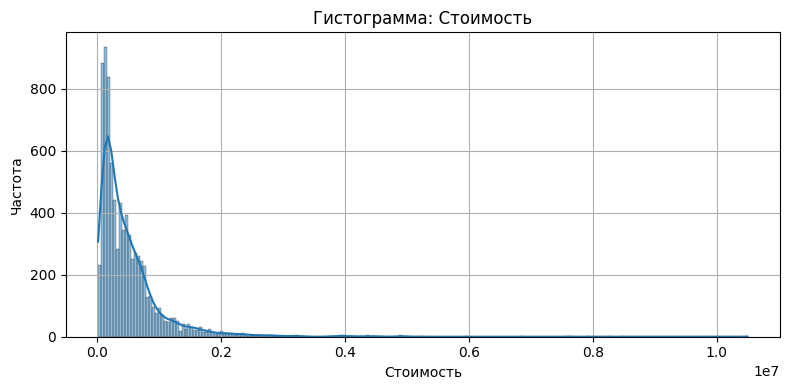

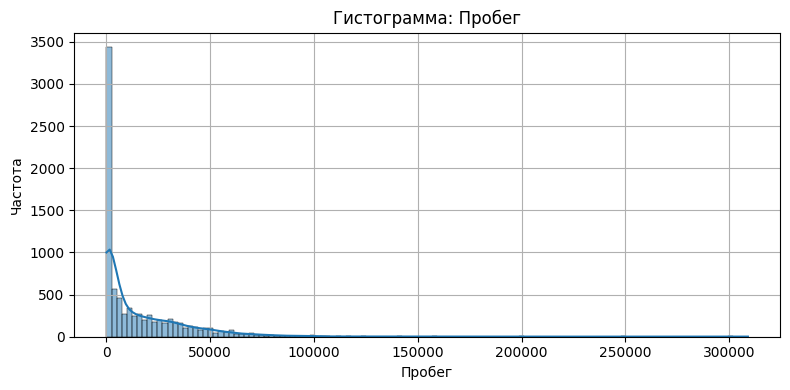

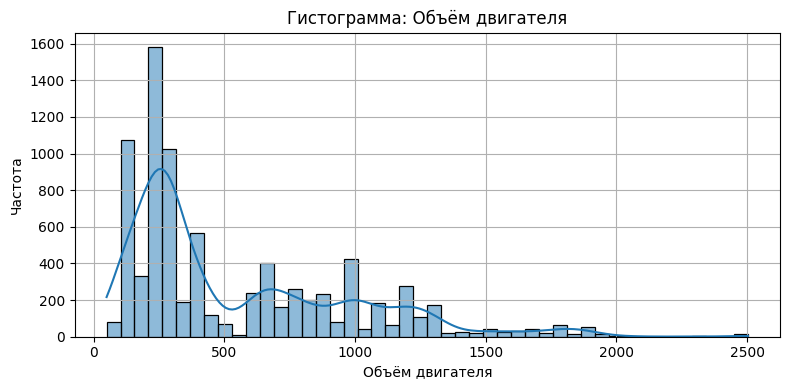

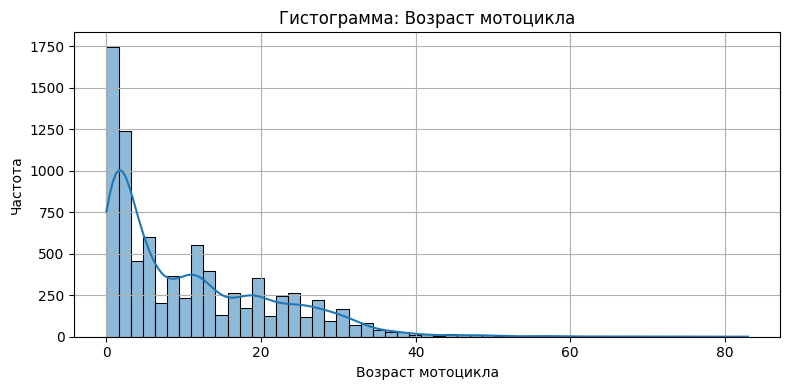

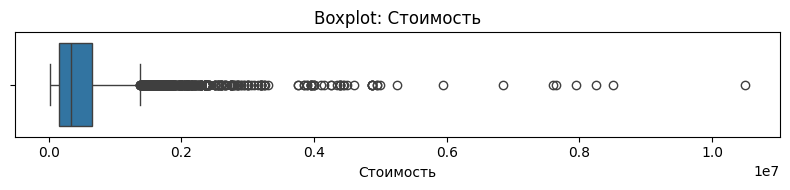

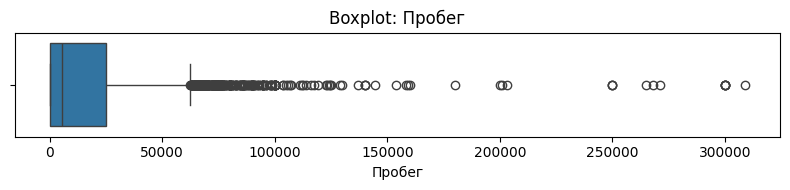

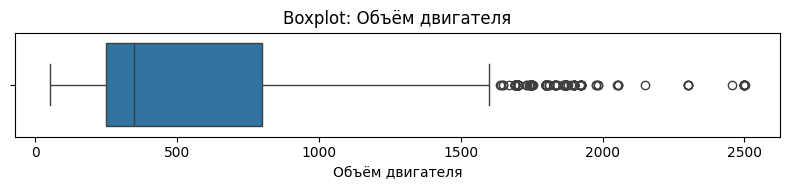

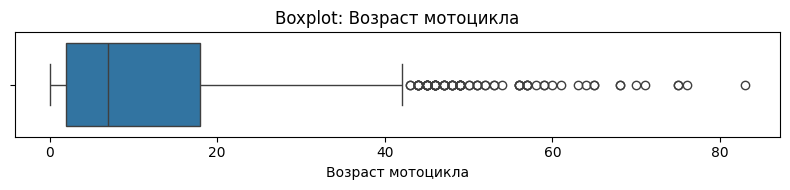

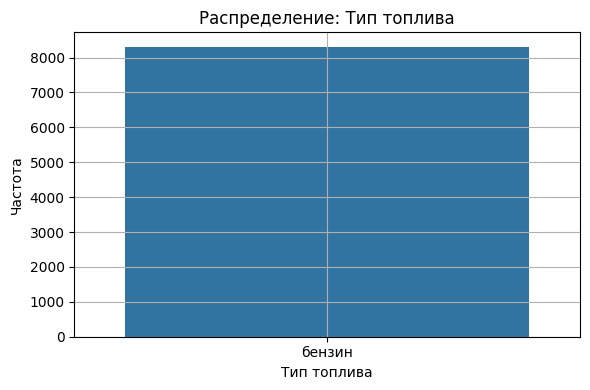

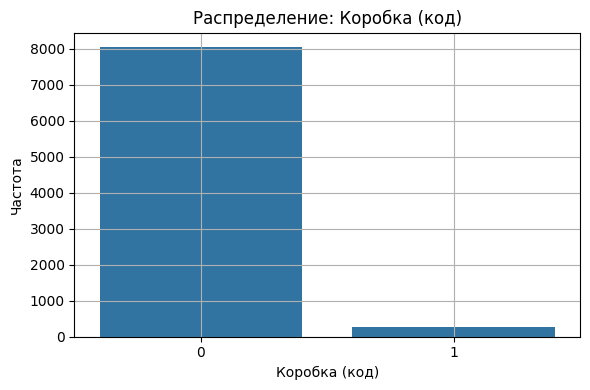

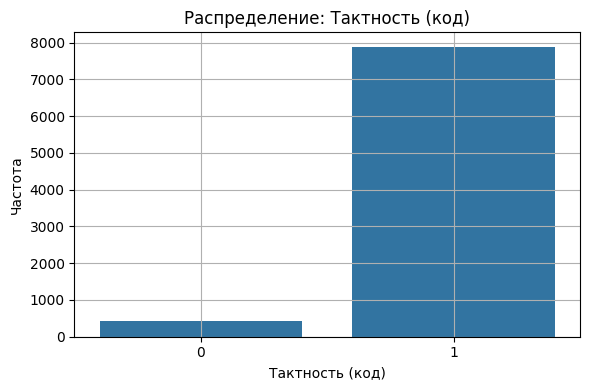

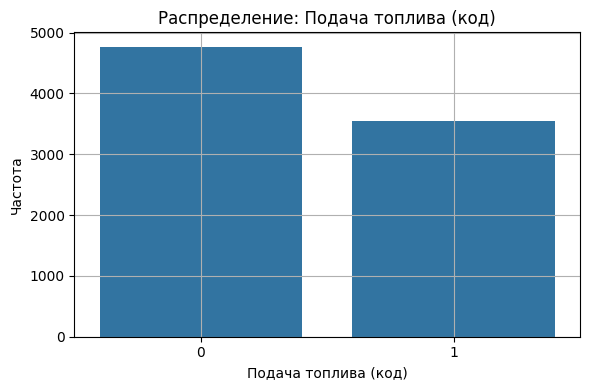

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

df = pd.read_csv("drom_cleaned.csv")

numeric_columns = ['Стоимость', 'Пробег', 'Объём двигателя', 'Возраст мотоцикла']
desc_stats = df[numeric_columns].describe().round(2)
print("Описательные статистики:\n")
print(tabulate(desc_stats, headers='keys', tablefmt='pretty'))

categorical_columns = ['Тип топлива', 'Коробка (код)', 'Тактность (код)', 'Подача топлива (код)']
for col in categorical_columns:
    print(f"\nРаспределение: {col}")
    print(df[col].value_counts())

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Гистограмма: {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for col in numeric_columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col])
    plt.title(f'Распределение: {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [12]:
df[['Стоимость', 'Пробег', 'Объём двигателя', 'Возраст мотоцикла']].corr()

,Стоимость,Пробег,Объём двигателя,Возраст мотоцикла
Стоимость,1.000000,0.062054,0.679042,-0.064846
Пробег,0.062054,1.000000,0.394481,0.520708
Объём двигателя,0.679042,0.394481,1.000000,0.280475
Возраст мотоцикла,-0.064846,0.520708,0.280475,1.000000


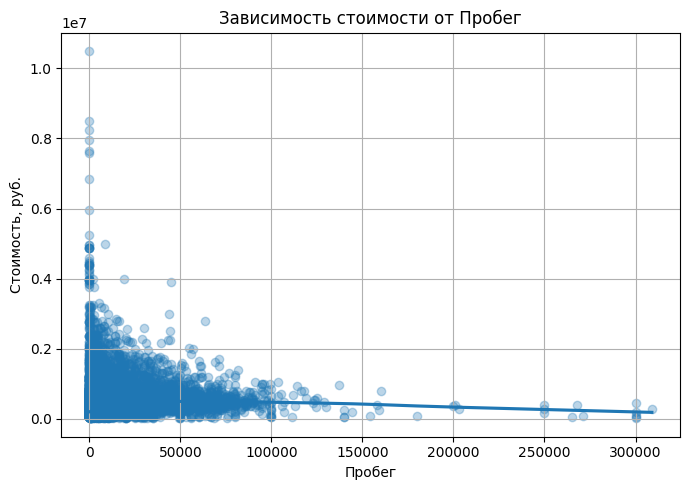

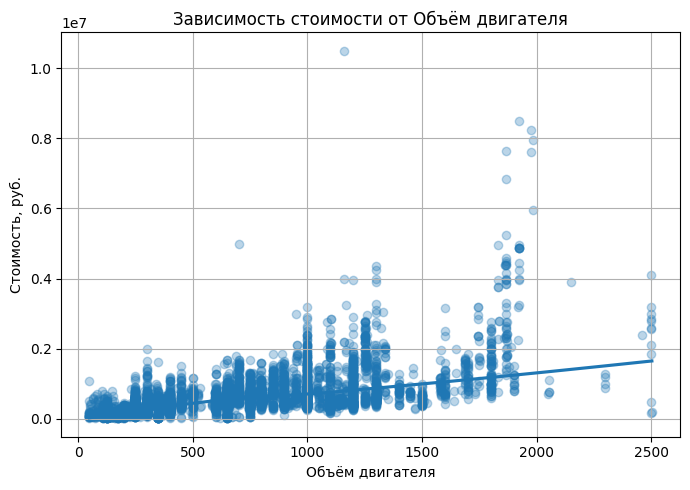

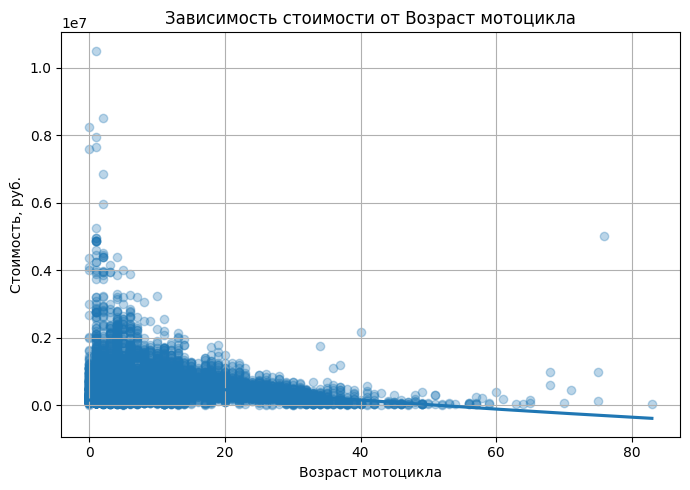

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("drom_cleaned.csv")

features = ['Пробег', 'Объём двигателя', 'Возраст мотоцикла']

for col in features:
    plt.figure(figsize=(7, 5))
    sns.regplot(data=df, x=col, y='Стоимость', lowess=True, scatter_kws={'alpha': 0.3})
    plt.title(f'Зависимость стоимости от {col}')
    plt.xlabel(col)
    plt.ylabel('Стоимость, руб.')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
